<a href="https://colab.research.google.com/github/dragoa/MachineLearning/blob/main/DeepLearning%20AI/%5BSPZ%5D%20PyTorch%20for%20Deep%20Learning/Module%203/PlantDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Kaggle API
!pip install -q kaggle
!pip install -q directory_tree

In [2]:
import pandas as pd
import torch
import os
from directory_tree import DisplayTree

import numpy as np

from torch.utils.data import Dataset, Subset, random_split, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from PIL import Image

from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USR")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE")

In [3]:
!kaggle datasets download -d marquis03/plants-classification
!unzip -q plants-classification.zip

Dataset URL: https://www.kaggle.com/datasets/marquis03/plants-classification
License(s): apache-2.0
plants-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
!cp /content/val.csv /content/val/df_labels.csv

### Dataset

For this scope we gonna use a subset of the dataset (the validation part of about 3k samples).

In [5]:
def print_dataset_structure(root_dir, max_depth=1):

  config_tree = {
        "dirPath": root_dir,
        "onlyDirs": False,
        "maxDepth": max_depth,
        "sortBy": 1,  # Sort by type (files first, then folders)
    }
  DisplayTree(**config_tree)

In [6]:
path_dataset = "/content/val/"

print_dataset_structure(path_dataset)

val/
├── classname.txt
├── df_labels.csv
├── aloevera/
├── banana/
├── bilimbi/
├── cantaloupe/
├── cassava/
├── coconut/
├── corn/
├── cucumber/
├── curcuma/
├── eggplant/
├── galangal/
├── ginger/
├── guava/
├── kale/
├── longbeans/
├── mango/
├── melon/
├── orange/
├── paddy/
├── papaya/
├── peperchili/
├── pineapple/
├── pomelo/
├── shallot/
├── soybeans/
├── spinach/
├── sweetpotatoes/
├── tobacco/
├── waterapple/
└── watermelon/


You now have an initial understanding of the dataset structure:
- `df_labels.csv`,
- `classname.txt`,
- One folder per class, each containing the images for that class (all in `.jpg` format).


In [7]:
# Mapping each sample to a category of plant (class)
df_labels = pd.read_csv(f"{path_dataset}/df_labels.csv")
df_labels.head()

,image:FILE,category
0,val/aloevera/aloevera700.jpg,0
1,val/aloevera/aloevera701.jpg,0
2,val/aloevera/aloevera702.jpg,0
3,val/aloevera/aloevera703.jpg,0
4,val/aloevera/aloevera704.jpg,0


In [8]:
# List of all my classes
with open(f"{path_dataset}/classname.txt", 'r') as f:
  class_names = f.read().splitlines()

print(class_names)

['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']


### Creating a Custom Dataset

In [9]:
class PlantDataset(Dataset):


  def __init__(self, root_dir, transform=None):
    """
    Initialize vars
    """
    self.root_dir = root_dir
    self.transform = transform
    self.df_info = self.read_df()
    self.labels = self.load_labels(self.df_info)
    self.class_names = self.read_class_names()
    self.error_logs = []


  def __len__(self):
    """
    Return the lenght of the dataset
    """
    return len(self.labels)


  def __getitem__(self, idx):
    """
    Return a tuple image and label and applies transforms
    """
    # loop to prevent an infinite loading
    for _ in range(len(self)):
      try:
        # retrieve image
        image = self.retrieve_image(idx)

        # apply any transform if needed
        if self.transform:
          image = self.transform(image)

        # retrieve label
        label = self.labels[idx]

        # return image and label
        return image, label

      except Exception as e:
        self.log_errors(idx, e)
        # move to the next idx
        idx = (idx + 1) % len(self)


  def read_df(self):
    """
    Read the df_labels file
    """
    df_labels = pd.read_csv(f"{self.root_dir}/df_labels.csv")
    return df_labels


  def load_labels(self, df_labels):
    """
    Function to load the labels from file
    """
    labels = []

    for _, row in df_labels.iterrows():
      label = row["category"]
      labels.append(label)

    return labels


  def read_class_names(self):
    """
    Returns:
      list: A list of class names, each as a string, read from the file.
    """
    with open(f"{self.root_dir}/classname.txt", 'r') as f:
      class_names = f.read().splitlines()

    return class_names


  def retrieve_image(self, idx):
    """
    Return the image correspondent to a specific index
    """
    # construct img name
    img_name = self.df_info["image:FILE"].iloc[idx].removeprefix("val/")
    img_path = os.path.join(self.root_dir, img_name)

    with Image.open(img_path) as img:
      # convert image to RGB if needed
      image = img.convert("RGB")

    return image


  def get_label_description(self, label):
    """
    Retruns the label description
    """
    return self.class_names[label]


  def log_errors(self, idx, e):
    """
    Function to log any errors during loading
    """
    img_name = self.df_info["image:FILE"].iloc[idx].removeprefix("val/")
    img_path = os.path.join(self.root_dir, img_name)

    self.error_logs.append({
        "index": idx,
        "error": str(e),
        "path": img_path
    })

    print(f"Skipping image at index {idx} with error {str(e)}")


  def error_summary(self):
    """
    Returns a summary of all errors
    """
    if not self.error_logs:
      print("No errors were detected")
    else:
      print(self.error_logs)

In [10]:
plant_dataset = PlantDataset(path_dataset, transform=None)

print(f"The lenght of the plant dataset is of {len(plant_dataset)} samples")

The lenght of the plant dataset is of 3000 samples


Image shape: (269, 187)


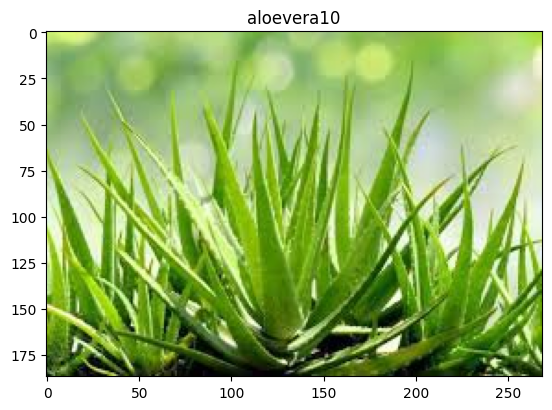

In [11]:
idx = 10
img, label = plant_dataset.__getitem__(idx)

plt.imshow(img)
plt.title(plant_dataset.get_label_description(label)+str(idx))

print(f"Image shape: {img.size}")

In [12]:
def vizualize_images(dataset, n_rows, n_cols):
  """
  Display random set of images from our dataset
  """
  total = n_rows * n_cols
  indicies = np.random.choice(len(dataset), total, replace=False)

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))

  # flattens into 1D array
  axes = axes.ravel()

  for ax, idx in zip(axes, indicies):
    image, label = dataset[idx]

    ax.imshow(image)
    ax.set_title(
        f"{label} - {dataset.get_label_description(label)}",
        fontsize=9)
    ax.axis("off")

  plt.tight_layout()
  plt.show()

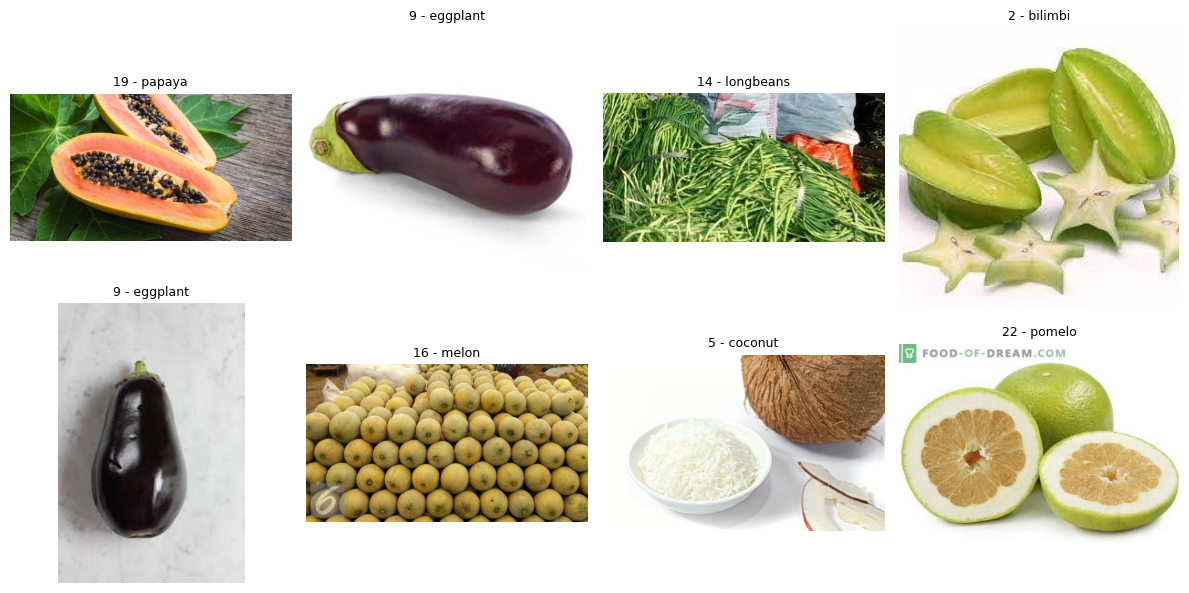

In [13]:
vizualize_images(plant_dataset, 2, 4)

From the visual exploration, you can see that the images in the dataset vary in size, color, and background. This kind of variability is common in real-world datasets and underscores the importance of preprocessing steps such as resizing, normalization, and data augmentation to help the model generalize effectively across different types of images.


### Transformations
Before feeding images into a neural network, you need to preprocess them using a series of transformations.
These steps include resizing the images to a consistent size, converting them into tensors, and normalizing their pixel values.

#### Compute Mean and STD
Since resizing and converting images to tensors changes the pixel value distribution, the mean and standard deviation must be computed after these transformations are applied.

In `get_mean_std`, you will:

* **Preprocessing Setup**:
A transform pipeline resizes images to 128×128 and converts them to tensors.

* **First Pass — Compute Mean**:
For each image, the pixels are flattened, and the channel-wise pixel values are summed globally across the entire dataset.
Dividing by the total number of pixels yields the channel-wise mean.

* **Second Pass — Compute Standard Deviation**:
With the mean known, we compute the squared difference between each pixel and its channel mean, accumulate across the dataset, and then take the square root to obtain the channel-wise standard deviation.

**Note**:
The mean and standard deviation should usually be computed only on the training set.
Using statistics computed from the test or validation data can introduce data leakage, where information from the evaluation set influences the training process.
In this case, since at this point the data has not yet been split, you will compute the statistics on the entire dataset for simplicity.
The mean and standard deviation values you obtain here will not change much when computed solely on the training set.

In [14]:
def get_mean_std(dataset):
  # define transformations: resize + to tensor
  transform = transforms.Compose([
      transforms.Resize((128,128)),
      # shape is (3, 128, 128)
      transforms.ToTensor()
  ])

  # mean calculation
  total_n_pixels = 0
  sum_pixels = torch.zeros(3)

  # wrap dataset in tqdm to visualize progress bar
  tqdm_dataset = tqdm(dataset, desc="Pass 1/2 computing mean...")

  for img, _ in tqdm_dataset:
    img_tensor = transform(img)
    # flattens the image per channel
    pixels = img_tensor.view(3, -1)
    # compute the sum of the pixels per channel
    sum_pixels += pixels.sum(dim=1)
    # total number of pixels (equal per channel 128x128)
    total_n_pixels += pixels.size(1)

  mean = sum_pixels / total_n_pixels

  # wrap dataset in tqdm to visualize progress bar
  tqdm_dataset = tqdm(dataset, desc="Pass 2/2 computing std...")
  sum_squared_diff = 0

  for img, _ in tqdm_dataset:
    img_tensor = transform(img)
    pixels = img_tensor.view(3, -1)
    diff = pixels - mean.unsqueeze(1)
    sum_squared_diff += (diff**2).sum(dim=1)

  std = torch.sqrt(1/total_n_pixels * sum_squared_diff)

  return mean, std

In [15]:
mean, std = get_mean_std(plant_dataset)

print(f"Mean: {mean}")
print(f"Std: {std}")

Pass 1/2 computing mean...:   0%|          | 0/3000 [00:00<?, ?it/s]

Pass 2/2 computing std...:   0%|          | 0/3000 [00:00<?, ?it/s]

Mean: tensor([0.6659, 0.6203, 0.4784])
Std: tensor([0.2888, 0.2884, 0.3426])


#### Create Transformations

Having computed the mean and standard deviation of the dataset, we can now define the transformations to apply to the images.
You’ll create two sets of transformations: one for the training set, which includes data augmentation, and another for the validation and test sets.

In [16]:
def get_transformations(mean, std):

  main_transformations = [
      transforms.Resize((128,128)),
      transforms.ToTensor(),
      transforms.Normalize(mean=mean, std=std)
  ]

  augmentation_transformations = [
      transforms.RandomVerticalFlip(),
      transforms.RandomRotation(degrees=15)
  ]

  # Compose transformations in one unique pipeline
  main_transform = transforms.Compose(main_transformations)
  aug_transform = transforms.Compose(augmentation_transformations + main_transformations)

  return main_transform, aug_transform


In [17]:
main_transform, aug_transform = get_transformations(mean, std)

print(main_transform)
print(aug_transform)

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.6659, 0.6203, 0.4784]), std=tensor([0.2888, 0.2884, 0.3426]))
)
Compose(
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.6659, 0.6203, 0.4784]), std=tensor([0.2888, 0.2884, 0.3426]))
)


In [18]:
def denormalize_image(tensor, mean, std):
  # compute the new mean for denormalize
  new_mean = [-m/s for m,s in zip(mean, std)]
  new_std = [1/s for s in std]

  denormalize = transforms.Normalize(mean=new_mean, std=new_std)

  return denormalize(tensor)

torch.Size([128, 128, 3])


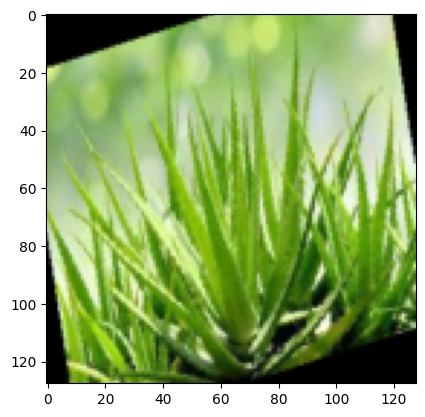

In [19]:
# apply transform on an image
img_transformed = aug_transform(img)
# denormalize image for visualization
img_transformed = denormalize_image(img_transformed, mean, std)

# permute function rearrange the dimensions the way matplotlib expects
img_transformed = img_transformed.permute(1,2,0)
print(img_transformed.size())

plt.imshow(img_transformed)

### Data Loading
With your custom dataset class and transformations defined, you can now create data loaders to efficiently load and batch data for training and evaluation. This is the final step before you would train a neural network on this dataset.

As in the previous lab, after using `random_split` to divide the dataset into training, validation, and test sets, you need to ensure that each subset uses the appropriate transformations.
One way to change the transformations of each subset is by wrapping the subsets in new instances of the custom dataset class `SubsetWithTransform`.

In [20]:
class SubsetWithTransform(Dataset):

  def __init__(self, subset: Subset, transform=None):
    # subset should be a subset WITHOUT transform
    self.subset = subset
    self.transform = transform


  def __len__(self):
    return len(self.subset)


  def __getitem__(self, index):
    img, label = self.subset[index]
    if self.transform:
      img = self.transform(img)

    return img, label

In [21]:
def get_dataloaders(dataset, batch_size, val_fraction, test_fraction, main_transform, aug_transform):
  """
  Splits a dataset into training, validation, and test sets, applies specified transforms to each split,
  and returns corresponding DataLoader objects.
  """
  total_size = len(dataset)
  val_size = int(val_fraction * total_size)
  test_size = int(test_fraction * total_size)
  train_size = total_size - val_size - test_size

  # Split the datasets using random splits
  train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

  # Wrap with Subset class to apply different transforms
  train_data = SubsetWithTransform(train_data, aug_transform)
  val_data = SubsetWithTransform(val_data, main_transform)
  test_data = SubsetWithTransform(test_data, main_transform)

  # Create the Dataloaders
  train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
  val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
  test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

  return train_dataloader, val_dataloader, test_dataloader

In [22]:
train_dataloader, val_dataloader, test_dataloader =  get_dataloaders(plant_dataset, 32, 0.15, 0.15, main_transform, aug_transform)

print('=== Train Loader ===')
print(f"Number of batches in train_loader: {len(train_dataloader)}")
train_dataset = train_dataloader.dataset
print(f"Number of samples in train_dataset: {len(train_dataset)}")
print(f"Transforms applied to train_dataset: {train_dataset.transform}")
print(f"train_dataset type: {type(train_dataset)}")

print('\n=== Test Loader ===')
print(f"Number of batches in test_loader: {len(test_dataloader)}")
test_dataset = test_dataloader.dataset
print(f"Number of samples in test_dataset: {len(test_dataset)}")
print(f"Transforms applied to test_dataset: {test_dataset.transform}")
print(f"test_dataset type: {type(test_dataset)}")

=== Train Loader ===
Number of batches in train_loader: 66
Number of samples in train_dataset: 2100
Transforms applied to train_dataset: Compose(
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.6659, 0.6203, 0.4784]), std=tensor([0.2888, 0.2884, 0.3426]))
)
train_dataset type: <class '__main__.SubsetWithTransform'>

=== Test Loader ===
Number of batches in test_loader: 15
Number of samples in test_dataset: 450
Transforms applied to test_dataset: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.6659, 0.6203, 0.4784]), std=tensor([0.2888, 0.2884, 0.3426]))
)
test_dataset type: <class '__main__.SubsetWithTransform'>
